# **Data Preparation**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("loveall/appliances-energy-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'appliances-energy-prediction' dataset.
Path to dataset files: /kaggle/input/appliances-energy-prediction


In [2]:
import glob
import math
import os
from statistics import mean, median

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import ticker
from scipy.stats import kurtosis, norm

In [3]:
# Path where kagglehub saved the extracted files
dataset_dir = (
    "/root/.cache/kagglehub/datasets/loveall/appliances-energy-prediction/versions/1"
)

# Find any CSV file inside that directory
csv_files = glob.glob(os.path.join(dataset_dir, "*.csv"))

if csv_files:
    # Load the first CSV file found
    df = pd.read_csv(csv_files[0])
    print(f"Successfully loaded: {csv_files[0]}\n")
    display(df.head())
else:
    # If it wasn't a CSV, list all extracted files to check the format
    print("Files in dataset directory:", os.listdir(dataset_dir))

Successfully loaded: /root/.cache/kagglehub/datasets/loveall/appliances-energy-prediction/versions/1/KAG_energydata_complete.csv



,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [5]:
df.tail()

# dataset contains data from 11/01 to 27/05 in Belgium.
# 01-02 - winter
# 03-05 - spring
# may contains seasonal effect

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.7,...,23.2,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.7,...,23.2,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.7,...,23.2,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.7,...,23.2,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784
19734,2016-05-27 18:00:00,430,10,25.500000,46.600000,25.264286,42.971429,26.823333,41.156667,24.7,...,23.2,46.8450,22.200000,755.2,57.000000,4.000000,27.000000,13.200000,34.118851,34.118851


In [6]:
# change date to datetime
df["date"] = pd.to_datetime(df["date"])

# set date as index
df.set_index('date', inplace=True)

# Check for missing value
df.isna().sum().sum()

np.int64(0)

# **Features Inspection**

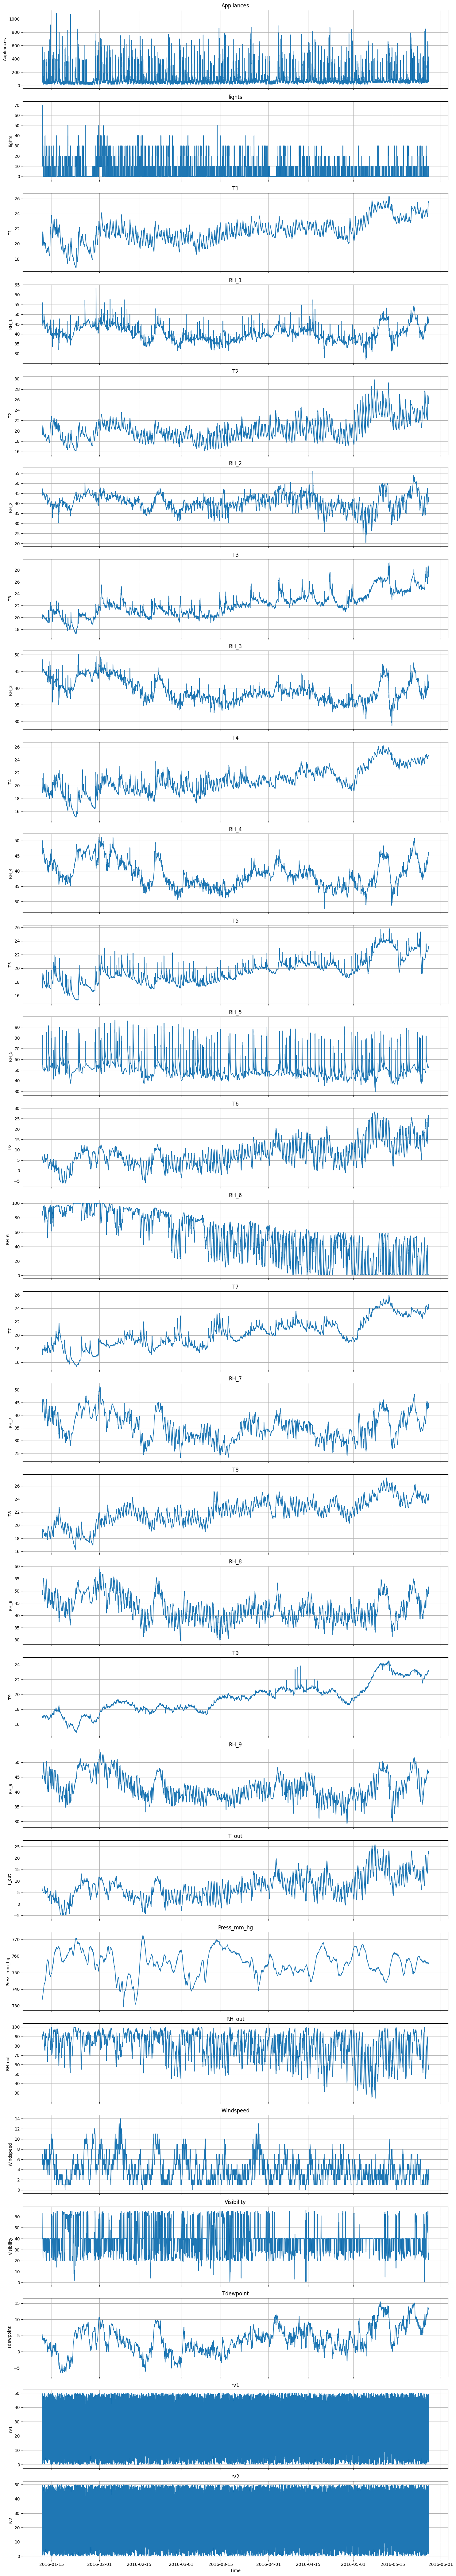

In [7]:
# visualize all numerical columns
num_cols = df.select_dtypes(include="number").columns

n = len(num_cols)

# Create vertical stack of subplots
fig, axes = plt.subplots(n, 1, figsize=(15, 3*n), sharex=True)

for i, col in enumerate(num_cols):
    axes[i].plot(df[col], color='tab:blue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel(col)
    axes[i].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

Some features may exhibit seasonal patterns. Fortunately, the XGB and LightGBM models can handle this.

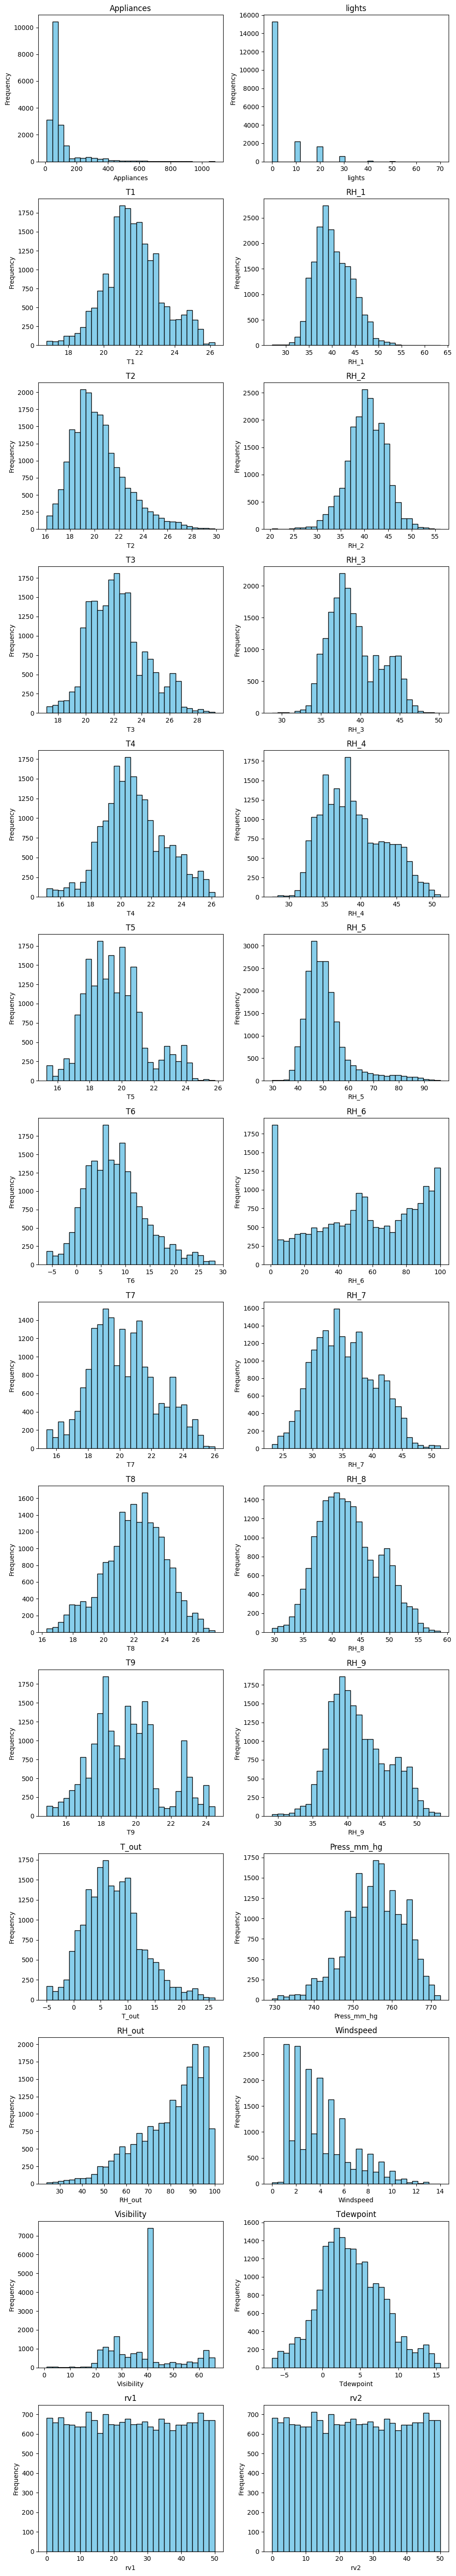

In [8]:
# Plot histogram for all numerical columns
cols_per_row = 2
rows = math.ceil(n / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(5*cols_per_row, 4*rows))
axes = axes.flatten()  # flatten for easy iteration

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

lights is a discrete variable. The others are continuous variables.

# **Target Inspection**

In [9]:
# target feature
target = df["Appliances"]
target.describe()

# mean > median
# right skewed kurtosis

,Appliances
count,19735.000000
mean,97.694958
std,102.524891
min,10.000000
25%,50.000000
50%,60.000000
75%,100.000000
max,1080.000000


Kurtosis: 13.66409667104885


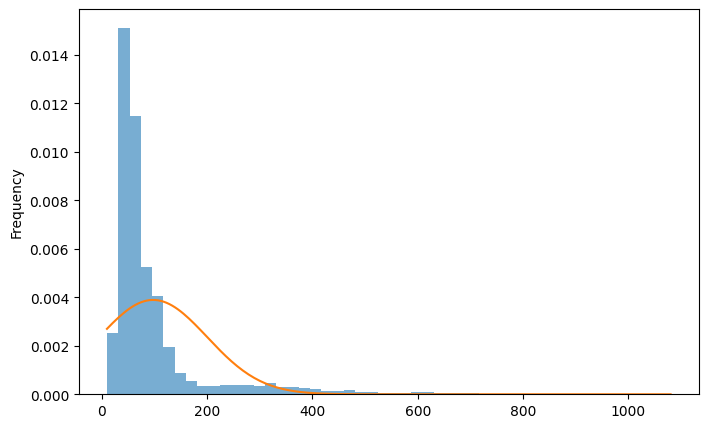

In [10]:
# check by histogram plot
print(f'Kurtosis: {kurtosis(target)}')

target.dropna().plot(
    kind='hist',
    bins=50,
    density=True,
    alpha=0.6,
    figsize=(8,5)
)

mu = target.mean()
sigma = target.std()

xx = np.linspace(target.min(), target.max(), 200)
plt.plot(xx, norm.pdf(xx, mu, sigma))
plt.show()

# distribution has a very long tail